In [71]:
# ===============================================================
# 1. Importer
# ===============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import warnings
warnings.filterwarnings("ignore")

In [72]:
# ===============================================================
# 2. Läs in dataset
# ===============================================================
df = pd.read_csv("Pokemon.csv")

In [73]:
# ===============================================================
# 3. Ta bort oönskade kolumner
# ===============================================================
df = df.drop(columns=["Type 2", "Legendary"], errors="ignore")

In [74]:
# ===============================================================
# 4. Definiera features och target
#    Target = 'Type 1'
# ===============================================================
y = df["Type 1"]
X = df[['HP','Attack','Defense','Sp. Atk','Sp. Def','Speed','Generation']]

# Encode target (multiklass)
label_enc = LabelEncoder()
y_encoded = label_enc.fit_transform(y)

In [75]:
# ===============================================================
# 5. Inställningar för experimentet
# ===============================================================
ks = [3, 7, 15]
scalings = ["original", "minmax"]
splits = [0.9, 2/3, 0.5]   # train_size

results = []

In [76]:
# ===============================================================
# 6. Kör alla 18 experiment
# ===============================================================
for k in ks:
    for scaling in scalings:

        # Skalning eller ej
        if scaling == "minmax":
            scaler = MinMaxScaler()
            X_proc = scaler.fit_transform(X)
        else:
            X_proc = X.values

        for train_size in splits:

            # Stratifiera eftersom target är multiklass
            X_train, X_test, y_train, y_test = train_test_split(
                X_proc, y_encoded,
                train_size=train_size,
                stratify=y_encoded,
                random_state=42
            )

            # Modell
            clf = KNeighborsClassifier(n_neighbors=k)
            clf.fit(X_train, y_train)

            # Prediktioner
            y_pred = clf.predict(X_test)

            # Metriker
            cm = confusion_matrix(y_test, y_pred)
            acc = accuracy_score(y_test, y_pred)

            results.append({
                "k": k,
                "scaling": scaling,
                "train_size": train_size,
                "accuracy": acc,
                "confusion_matrix": cm
            })

In [77]:
# ===============================================================
# 7. Sammanställ resultat i tabell
# ===============================================================
summary = pd.DataFrame([{
    "k": r["k"],
    "scaling": r["scaling"],
    "train_pct": f"{int(r['train_size']*100)}%",
    "accuracy": round(r["accuracy"], 4)
} for r in results])

summary_sorted = summary.sort_values(by="accuracy", ascending=False).reset_index(drop=True)

print("==== Resultattabell (alla 18 körningar) ====")
display(summary_sorted)

==== Resultattabell (alla 18 körningar) ====


,k,scaling,train_pct,accuracy
0,15,minmax,90%,0.2750
1,15,original,50%,0.2225
2,7,original,66%,0.2135
3,7,original,90%,0.2125
4,7,minmax,90%,0.2125
5,15,original,66%,0.2097
6,15,minmax,66%,0.2097
7,7,minmax,66%,0.2060
8,7,original,50%,0.1850
9,7,minmax,50%,0.1775



==== Topp 3 körningar ====

Rank 1
k = 15, scaling = minmax, train = 90%
Accuracy = 0.275
Confusion matrix:
[[1 1 0 0 0 0 0 1 1 0 0 0 0 0 0 1 2]
 [0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1]
 [0 0 0 0 0 0 2 0 2 0 0 0 0 0 0 0 0]
 [0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1]
 [0 0 1 0 0 0 1 0 1 0 0 1 0 0 0 0 1]
 [0 0 0 0 0 0 0 2 0 0 0 0 0 1 0 0 0]
 [0 0 0 1 0 0 0 1 2 0 1 0 0 0 0 0 2]
 [0 0 0 0 0 0 0 0 0 1 0 2 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1]
 [3 0 0 0 0 0 1 0 0 0 0 4 0 0 0 0 2]
 [0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 4 0 0 1]
 [0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 2 0]
 [0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [2 1 0 0 0 0 2 0 1 0 0 1 0 1 0 0 3]]
----------------------------------------
Rank 2
k = 15, scaling = original, train = 50%
Accuracy = 0.2225
Confusion matrix:
[[ 8  0  1  1  0  1  1  0  0  5  1  0 13  0  1  1  1  1]
 [ 0  0  1  1  0  0  3  0  0  0  0  0  4  1  0  1  0  4]
 [ 0  1  4  0  0  0  2 

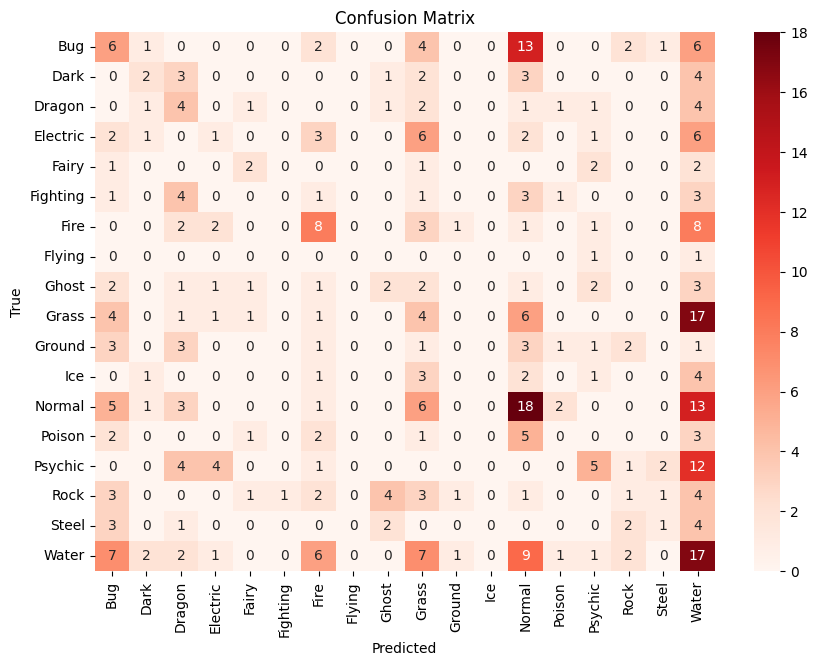

In [ ]:
# ===============================================================
# 8. Visa de tre bästa körningarna med confusion matrix
# ===============================================================
top3 = summary_sorted.head(3)

print("\n==== Topp 3 körningar ====\n")
for i, row in top3.iterrows():
    match = next(r for r in results
                 if r["k"] == row["k"]
                 and r["scaling"] == row["scaling"]
                 and f"{int(r['train_size']*100)}%" == row["train_pct"])
    
    print(f"Rank {i+1}")
    print(f"k = {match['k']}, scaling = {match['scaling']}, train = {row['train_pct']}")
    print(f"Accuracy = {round(match['accuracy'],4)}")
    print("Confusion matrix:")
    print(match["confusion_matrix"])
    print("-" * 40)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


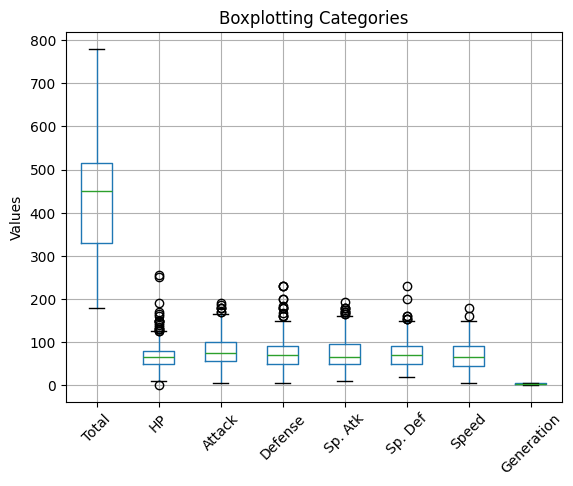

In [79]:
df_cols = ['Name', 'Type 1', 'Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation']
df[df_cols].boxplot(rot=45)
plt.title('Boxplotting Categories')
plt.ylabel('Values')
plt.show()